### OptionDX Data Analysis
This file is used to analyze the **OptionsDX SPY options chain data**.

The dataset contains 5 days of the full SPY option chain, with calls (`C_*`) and puts (`P_*`) laid out side-by-side around a shared `STRIKE`, along with the underlying spot (`UNDERLYING_LAST`), days to expiration (`DTE`), per-contract Greeks
(delta, gamma, vega, theta, rho), implied volatility (`*_IV`), volume, and bid/ask quotes.

### Installing packages
- Run `!mamba list "package_name"` command to check the package installation status. For example,

```python
!mamba list numpy
"""
# packages in environment at /opt/conda:
#
# Name                    Version                   Build  Channel
numpy                     1.21.6           py39h18676bf_0    conda-forge
"""
```

    You can also try importing the package.

- Run the `!mamba install "package_name"` to install a package

In [1]:
# %pip install numpy pandas matplotlib

# Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

''' 
    进行数据分析时：
    保留原始全量 data，让每个分析自己 .copy() 一份数据、切自己需要的子集。
    因为不同分析所需要的数据子集是不同的。

'''

data = pd.read_csv("spy_options_data.csv")

In [2]:
"Cell 1: Check the data"

'''
STRIKE:行权价
C_IV: call 的隐含波动率(Implied Volatility)
C_SIZE:报价深度,格式是 买盘量 x 卖盘量(bid size x ask size),比如 13 x 3，
        最优买价(best bid)和最优卖价(best ask)这两档上,各自有多少张合约在挂单
STRIKE_DISTANCE:现货价与行权价的绝对差,|UNDERLYING_LAST - STRIKE|,衡量这张期权离平值(ATM)多远。
STRIKE_DISTANCE_PCT:绝对差值的百分比形式

真正完整的"市场深度"(Market Depth / Level 2)是指每一个价位上各有多少挂单

PS：
结果里面 C_IV、C_VOLUME 等列明都是 object，说明这些列里混入了非数字
OptionsDX 这类数据源，遇到"无报价/无成交"的合约，会填空字符串 '' 或空格 ' '
'''

print('Data Shape:', data.shape)
print('\nColumns:',data.columns.tolist())

print("\nDtypes and non-null counts:")
data.info()

# Check the null
print("\nMissing values per column:")
print(data.isnull().sum())

# basic statistics
print("\nStatistics summary:")
data.describe()



Data Shape: (22962, 29)

Columns: [' [QUOTE_READTIME]', ' [UNDERLYING_LAST]', ' [EXPIRE_DATE]', ' [DTE]', ' [C_DELTA]', ' [C_GAMMA]', ' [C_VEGA]', ' [C_THETA]', ' [C_RHO]', ' [C_IV]', ' [C_VOLUME]', ' [C_LAST]', ' [C_SIZE]', ' [C_BID]', ' [C_ASK]', ' [STRIKE]', ' [P_BID]', ' [P_ASK]', ' [P_SIZE]', ' [P_LAST]', ' [P_DELTA]', ' [P_GAMMA]', ' [P_VEGA]', ' [P_THETA]', ' [P_RHO]', ' [P_IV]', ' [P_VOLUME]', ' [STRIKE_DISTANCE]', ' [STRIKE_DISTANCE_PCT]']

Dtypes and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 22962 entries, 0 to 22961
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0    [QUOTE_READTIME]       22962 non-null  str    
 1    [UNDERLYING_LAST]      22962 non-null  float64
 2    [EXPIRE_DATE]          22962 non-null  str    
 3    [DTE]                  22962 non-null  float64
 4    [C_DELTA]              22962 non-null  float64
 5    [C_GAMMA]              22962 non-null  floa

,[UNDERLYING_LAST],[DTE],[C_DELTA],[C_GAMMA],[C_VEGA],[C_THETA],[C_RHO],[STRIKE],[P_BID],[P_ASK],[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
count,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000,22962.000000
mean,412.189519,138.970752,0.550413,0.005174,0.716469,-0.065144,0.566004,405.132066,36.597309,37.453433,9.532670,-0.444805,0.005230,-0.218012,-0.109483,-0.355363,72.667917,0.176300
std,2.406663,194.733509,0.390358,0.008658,2.992692,0.066768,0.962501,98.648122,59.133160,59.972808,23.551259,0.387436,0.012591,18.051554,0.874308,0.592815,67.110491,0.162824
min,408.130000,0.000000,0.000000,-0.000030,0.000000,-0.835060,-0.088870,85.000000,0.000000,0.010000,0.000000,-1.000000,-0.000040,-825.599620,-18.131040,-4.600160,0.100000,0.000000
25%,410.720000,17.000000,0.096765,0.000530,0.044330,-0.094070,0.011020,353.000000,1.080000,1.120000,0.000000,-0.894415,0.000530,0.036812,-0.077705,-0.440020,24.100000,0.058000
50%,413.440000,45.000000,0.667640,0.002610,0.235285,-0.049810,0.166565,402.000000,11.105000,11.690000,0.510000,-0.337540,0.002790,0.244675,-0.038340,-0.089540,50.100000,0.122000
75%,414.200000,171.040000,0.934275,0.006387,0.659740,-0.010833,0.640195,452.000000,43.550000,44.775000,8.420000,-0.050620,0.006350,0.565748,-0.013673,-0.004700,99.400000,0.242000
max,414.410000,872.040000,1.000000,0.533450,59.667980,0.000000,12.202650,720.000000,311.390000,314.000000,326.570000,0.000000,1.387180,6.883450,0.000000,0.000000,329.400000,0.795000


In [ ]:
"Cell 2: Clean the dataset"
# Clean the column name
data.columns = data.columns.str.strip().str.strip('[]') 
# .str: pandas 的字符串访问器,.str 之后,就能对索引里的每一个元素逐个施加字符串操作
print("Cleaned columns:")
print(data.columns.tolist())

# Format Transversion
# numeric
numeric_cols = ['C_IV', 'C_VOLUME', 'C_LAST', 'C_SIZE', 'C_BID', 'C_ASK', 
                'STRIKE', 
                'P_BID', 'P_ASK', 'P_SIZE', 'P_LAST', 'P_VOLUME', 'P_IV']
"""
OptionsDX 这类数据源，遇到"无报价/无成交"的合约，会填空字符串 '' 或空格 ' '
errors='coerce' — 关键参数。遇到转不动的值（空字符串、乱码）不报错，而是转成 NaN（缺失值）。
"""

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# datetime
data["QUOTE_READTIME"] = pd.to_datetime(data["QUOTE_READTIME"], errors='coerce')
data['EXPIRE_DATE'] = pd.to_datetime(data["EXPIRE_DATE"], errors='coerce')

"""
数据转换完成后，C_VOLUME 出现 7395 个 NaN、P_VOLUME 7110 个——意味着约 32% 的合约当天零成交。
但是这里的所有的指标不能随意删除，需要根据具体分析再进行删减数据，比如 波动率分析 与 利差分析所需要的数据是不同的
"""

print("\nMissing values after cleaning:")
print(data.isnull().sum())


Cleaned columns:
['QUOTE_READTIME', 'UNDERLYING_LAST', 'EXPIRE_DATE', 'DTE', 'C_DELTA', 'C_GAMMA', 'C_VEGA', 'C_THETA', 'C_RHO', 'C_IV', 'C_VOLUME', 'C_LAST', 'C_SIZE', 'C_BID', 'C_ASK', 'STRIKE', 'P_BID', 'P_ASK', 'P_SIZE', 'P_LAST', 'P_DELTA', 'P_GAMMA', 'P_VEGA', 'P_THETA', 'P_RHO', 'P_IV', 'P_VOLUME', 'STRIKE_DISTANCE', 'STRIKE_DISTANCE_PCT']

Missing values after cleaning:
QUOTE_READTIME             0
UNDERLYING_LAST            0
EXPIRE_DATE                0
DTE                        0
C_DELTA                    0
C_GAMMA                    0
C_VEGA                     0
C_THETA                    0
C_RHO                      0
C_IV                     793
C_VOLUME                7395
C_LAST                     2
C_SIZE                 22962
C_BID                      2
C_ASK                      2
STRIKE                     0
P_BID                      0
P_ASK                      0
P_SIZE                 22962
P_LAST                     0
P_DELTA                    0
P_GAMMA   

***结论分析***
1. 成交量缺失，代表这张合约今天一笔都没成交。交易所会为一个标的挂出非常多的行权价,从深度实值一直铺到深度虚值,形成一长串 strike。
但真实交易高度集中在平值(ATM)附近——大家主要交易接近现价的那些合约。离现价越远(深 ITM 或深 OTM),合约越没人要:深 OTM 几乎注定一文不值,深 ITM 又太贵、且基本等同于直接持有标的,缺乏交易动机。

2. IV 缺失。 隐含波动率（IV）不是市场直接报出来的,而是通过定价公式反推出来的。
    
    为什么有些合约解不出 IV? 两种典型情况:
    
    深度实值、时间价值几乎为零:深 ITM 期权的价格几乎全是内在价值(intrinsic value),时间价值(extrinsic value)趋近于 0。而 IV 影响的恰恰是时间价值那部分。当时间价值小到接近 0 时,期权价格对波动率几乎"不敏感"——你怎么调波动率,理论价格都几乎不变。这种情况下数值反解会不收敛或解出无意义的值,于是干脆留空。

    打个比方:IV 反解就像"通过测水温反推炉火大小"。但如果锅里几乎没水(时间价值≈0),水温这个信号就失灵了,你没法靠它推断火候——IV 也就解不出来。

    报价缺失/不可靠:如果某合约连像样的 bid/ask 或成交价都没有，连"输入价格"都不可信,自然也解不出 IV。

In [18]:
"Cell 3: Market Making Indicators"
# Mid Price
data['C_MID'] = (data["C_BID"] + data["C_ASK"]) / 2
data['P_MID'] = (data["P_BID"] + data["P_ASK"]) / 2

# Absolute Spread = Ask - Bid
data['C_SPREAD'] = data['C_ASK'] - data['C_BID']
data['P_SPREAD'] = data['P_ASK'] - data['P_BID']

# Relative Spread = Absolute Spread / Mid Price
data['C_REL_SPREAD'] = data['C_SPREAD'] / data['C_MID'].replace(0, np.nan)
data['P_REL_SPREAD'] = data['P_SPREAD'] / data['P_MID'].replace(0, np.nan)

'''
    相对化价差：
    A 期权：mid = $100，spread = $1 → 相对价差 1%
    B 期权：mid = $1，spread = $1 → 相对价差 100%

    绝对价差都是 $1，但 B 的流动性差得多。只有相对价差能跨不同价格水平的合约公平比较流动性。
'''

# Moneyness: Strike relative to spot. >0 = strike above spot
data['MONEYNESS_PCT'] = (data['STRIKE'] / data['UNDERLYING_LAST'] - 1)*100
data['LOG_MONEYNESS'] = np.log(data['STRIKE'] / data['UNDERLYING_LAST'])

# Basic Info about the option sheet
print('Quote Range:', data['QUOTE_READTIME'].min(), '-', data['QUOTE_READTIME'].max())
print("Expires:", data['EXPIRE_DATE'].nunique())
print('Strikes Range:', data['STRIKE'].min(), '-', data['STRIKE'].max())
print("Spot Range  :", data['UNDERLYING_LAST'].min(), "-", data['UNDERLYING_LAST'].max())


# Dead Quotes
''' 
    一个合约如果 bid = 0 或 bid 缺失（NaN），意味着市场上没有任何人愿意出价买它。
    "死报价"，名义上挂在那但没有真实的双边市场，直接反映数据里有多少合约是"僵尸合约"、不可做市。
'''
dead_calls = (data['C_BID'].fillna(0) == 0).mean()
dead_puts = (data['P_BID'].fillna(0) == 0).mean()
print(f"\nCalls with zero/NaN bid: {dead_calls:.1%}")
print(f"Puts  with zero/NaN bid: {dead_puts:.1%}")


Quote Range: 2022-08-01 16:00:00 - 2022-08-05 16:00:00
Expires: 36
Strikes Range: 85.0 - 720.0
Spot Range  : 408.13 - 414.41

Calls with zero/NaN bid: 3.1%
Puts  with zero/NaN bid: 0.0%


Total contracts in analysis: 12123

Median relative spread (%)  rows: moneyness, cols: DTE:
dte_bucket  0-7d  8-30d  31-90d  91-180d  181-365d
m_bucket                                          
<-10%        NaN    4.6     1.1      0.8       4.5
-10~-5%      7.4    1.7     0.6      0.6       2.0
-5~-2%       2.5    0.9     0.6      0.4       3.0
ATM ±2%      1.0    0.7     0.5      0.4       2.9
2~5%         3.4    1.3     0.7      0.5       1.7
5~10%        NaN    3.9     1.3      0.8       2.3
>10%         NaN    8.0     3.4      2.1       4.8


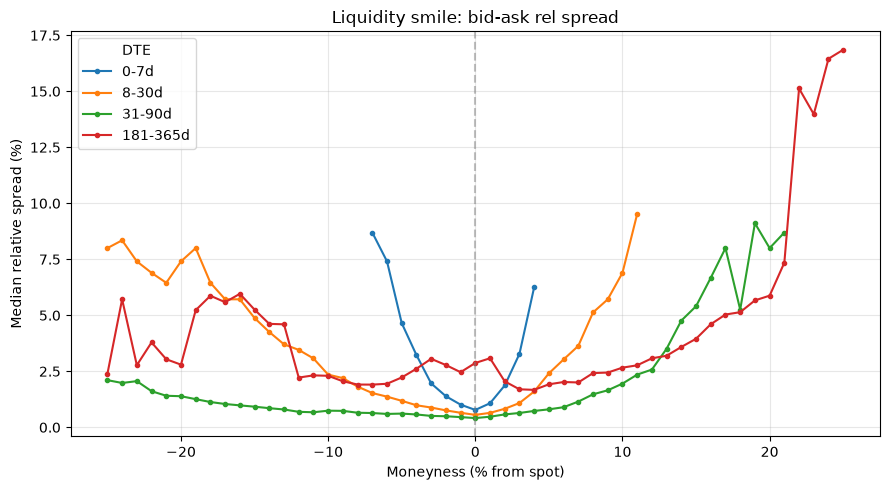

In [19]:
"Cell 4: Spread Analysis"

# focus on the tradable surface: set the moneyness +- 25% and within 1 year.
liq = data[(data['MONEYNESS_PCT'].abs() <= 25) & (data['DTE'] <= 365)].copy()
# 原始数据 strike 从 85 铺到 720、到期到 872 天，
# 混了大量深度价内外和超长 LEAPS——这些几乎不成交、价差宽到没有分析意义（噪声）。

# 取价外侧的期权
# 根据 put-call parity，只要知道了 call 和 put 的一个，另一个基本就定了
# 所以同一个 strike 上,call 和 put 携带的信息高度冗余，只需要保留一个就行

is_call_side = liq['STRIKE'] >= liq['UNDERLYING_LAST']
liq['rel_spread'] = np.where(is_call_side, liq['C_REL_SPREAD'], liq['P_REL_SPREAD'])
liq['mid'] = np.where(is_call_side, liq['C_MID'], liq['P_MID'])
liq['bid'] = np.where(is_call_side, liq['C_BID'], liq['P_BID'])

liq = liq[
    (liq['bid'] > 0) &              # 剔除死报价，没有真实买价的合约，价差无意义。
    (liq['mid'] >= 0.10) &          # drop sub-tick artifact
    (liq['rel_spread'] > 0) &       # drop zero spreads
    (liq['rel_spread'] < 2)
].copy()

''' 
短期 + 低价 情况下的 Spread Analysis：
liq = liq[
    (liq['bid'] > 0) &              # 剔除死报价，没有真实买价的合约，价差无意义。
    (liq['mid'] >= 0.10) &          # drop sub-tick artifact
    (liq['rel_spread'] > 0) &       # drop zero spreads
    (liq['rel_spread'] < 2)
].copy()
'''

print(f'Total contracts in analysis: {len(liq)}')

# Bucket moneyness and DTE
# pd.cut 把连续值切成离散档（分桶）
liq['m_bucket'] = pd.cut(liq['MONEYNESS_PCT'],
                         bins=[-25, -10, -5, -2, 2, 5, 10, 25],
                         labels=['<-10%','-10~-5%','-5~-2%','ATM ±2%','2~5%','5~10%','>10%'])

liq['dte_bucket'] = pd.cut(liq['DTE'],
                           bins=[-1, 7, 30, 90, 180, 365],
                           labels=['0-7d','8-30d','31-90d','91-180d','181-365d'])

# Spread Analysis
# 聚合方式： Median
# 价差分布是右偏的（大多数很小，少数很大），均值会被那些极端大值拉高，不能代表"典型水平"。
pivot = liq.pivot_table(values='rel_spread', index='m_bucket',
                        columns='dte_bucket', aggfunc='median', observed=True)
print("\nMedian relative spread (%)  rows: moneyness, cols: DTE:")
print((pivot * 100).round(1))

# Liquidity smile plot
fig, ax = plt.subplots(figsize=(9, 5))
for dte_lbl in ['0-7d','8-30d','31-90d','181-365d']:
    sub = liq[liq['dte_bucket'] == dte_lbl]
    grp = sub.groupby(sub['MONEYNESS_PCT'].round())['rel_spread'].median()
    ax.plot(grp.index, grp.values * 100, marker='.', label=dte_lbl)
ax.set_xlabel('Moneyness (% from spot)')
ax.set_ylabel('Median relative spread (%)')
ax.set_title('Liquidity smile: bid-ask rel spread')
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.legend(title='DTE')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 价差分析
#### bid：做市商的最高买价；ask：做市商的最低卖价

***价差分析：***
- 做市商不保证同时成交 bid 和 ask，也无法"确保"有人来吃单。
-  Market Maker 的核心风险：库存风险，即如果只有一边成交怎么办？
- MM 的盈利 = 价差 - 库存风险损失

***应对方法：***
1. 库存偏移：如果你多头库存太多（一直被吃 bid），你就把整个报价往下移——降低 ask（比如从 $1.10 降到 $1.05），让你的 ask 更有吸引力，主动鼓励别人来买、帮你卸掉库存；
同时也降低 bid，让别人更不愿意再卖给你。反过来，空头库存太多，就整体上移报价，鼓励别人卖给你。
MM 需要根据当前库存动态地左右挪动报价，经典模型：Avellaneda-Stoikov

2. 用标的对冲（Delta Hedging）：
买入一份 call 库存后，立刻在标的市场卖出对应数量的 SPY 来对冲掉方向（delta）敞口。

***保留 OTM 的原因：***
1. 价外期权是市场真正活跃交易的主体。绝大多数投机、对冲、做市报价都集中在 OTM 合约上。
2. 价外期权全是时间价值,没有内在价值。它的价格纯粹反映"市场对波动的预期"，做 IV 曲面、波动率分析时信息最干净。
3. 价内期权的报价往往更脏:价差宽、成交稀,而且它的价值大头是内在价值(现价 - strike 那部分),时间价值占比小,IV 反解容易失真——这跟你之前学的"深 ITM 算不出 IV"是一脉相承的。

PS：此处的相对价差 rel_spread 来自 call 和 put，而不是仅仅来自于 call or put，原因是：价差分析的目的是分析"流动性 / 交易成本"随 Moneyness 如何变化，相对价差才能反映"交易这张期权要付出的成本占其价值的比例"，同时价外侧 OTM 侧 mid 干净(纯时间价值),跨 strike 可比。如果你两侧 ITM/OTM 混着用 rel_spread,曲线会被"分母大小不同"污染。

***期权数据质量过滤：*** 
1. bid > 0：去掉死报价（没人愿意买的合约，即上一块算过的 3.1%）。没有真实买价的合约，价差无意义。
2. mid >= 0.10：
    - 相对价差 = spread/mid。SPY 期权最小变动单位（tick）是 $0.01。对一个 mid = $0.02 的便宜期权：哪怕只差一个 tick，spread = $0.01，相对价差 = 0.01/0.02 = 50%！
    - 此处 50% 不代表"流动性差"，而是离散定价的数学假象——价格太小，一个 tick 占比就巨大。如果不过滤，这些便宜合约的相对价差会虚高到 100-200%，把整张分析图污染掉。所以设一个 mid 地板（$0.10），把这些"价格太小导致失真"的合约排除。
3. rel_spread > 0 — 去掉交叉报价（ask < bid，算出负价差）或零价差等异常。
4. rel_spread < 2 — 去掉剩余极端值（价差超过 mid 两倍的，基本是脏数据）。

### 结论分析：
1. 任何一条线，最低点都在 moneyness=0（ATM）附近。

    - 逆向选择（adverse selection）—— 深度价内外成交稀少，谁来交易更可能是知情者，MM 挂宽价差自保；ATM 成交活跃、信息对称，敢挂窄。
    - 竞争：ATM 是所有 MM 都想做的"黄金地段"，竞争激烈把价差压到最薄；两翼参与者少，竞争弱，价差自然宽。
    - 对冲难度 + 价格水平：两翼期权要么很贵（深度价内）要么很便宜（深度价外），对冲成本和相对价差天然更高。

2. 四条线整体高低不同 —— 期限 U 型

    - 短端贵（0-7d）：两个原因。一是 mid 价格小（临近到期时间价值低），相对价差天然偏高；二是 gamma 风险高——临近到期，delta 对标的变动极度敏感，MM 对冲频繁、风险大，要补偿。
    - 长端贵（181-365d）：成交稀疏 + vega 风险高——长期期权对 IV 极度敏感，MM 持有长期库存背着大额、难对冲的波动率敞口，压在手里久、风险大，要补偿。
    - 中段甜区（31-180d）：成交活跃 + 两种风险都适中，价差最薄。
    - 短期风险 = Gamma 风险；长期风险 = Vega 风险。

3. 表里的 NaN 

    - rel spread 是衡量流动性的好指标，但仅在期权价格足够高的区域有效。在短期 + 远价外（低价）区域，rel spread 被 tick size 机械放大，不再反映真实流动性。
    - 短期 + 远价外 的特点是，由于期权即将到期，时间价值极小，同时由于在远价外，本身的期权价值也极小，因此很容易导致 rel spread 过大。

Snapshot:2022-08-05 16:00:00 | Spot:413.44


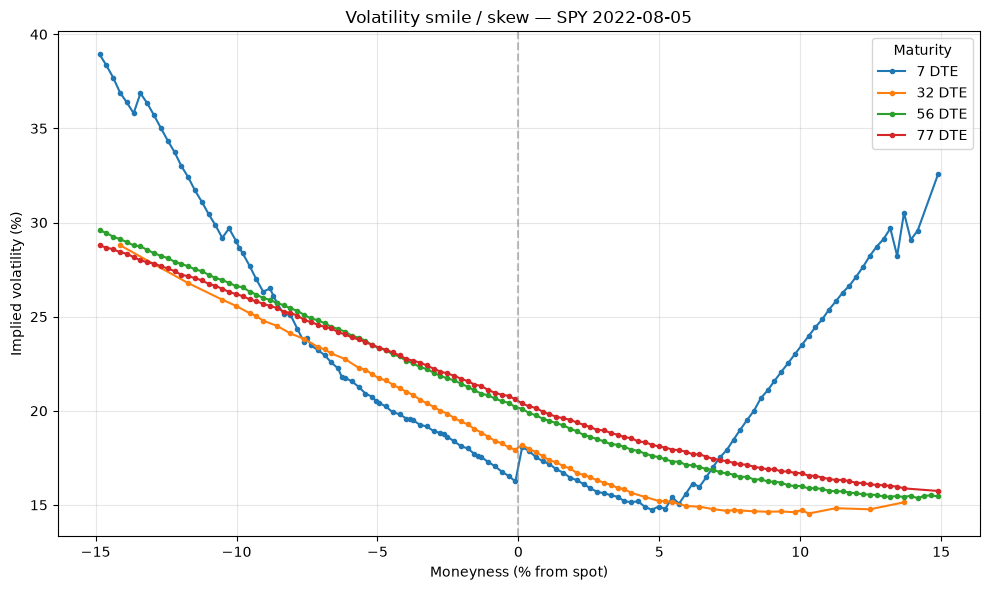

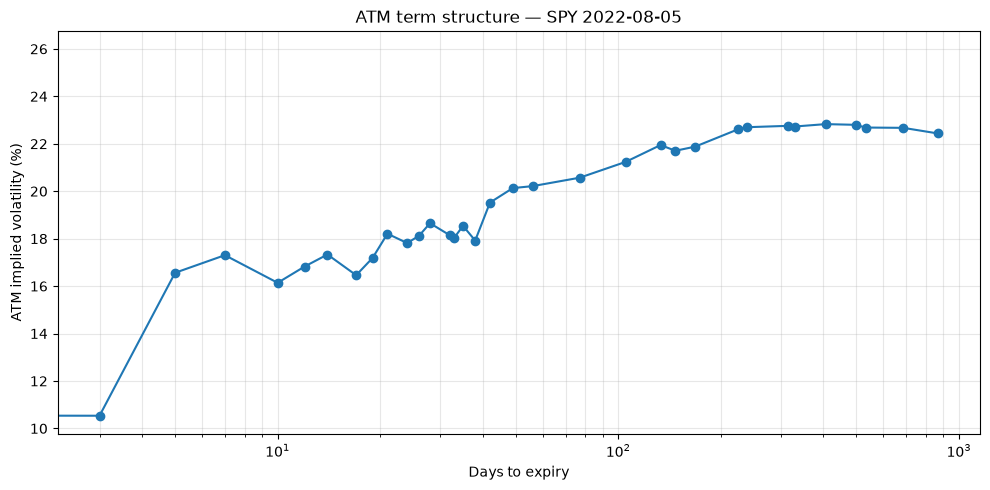

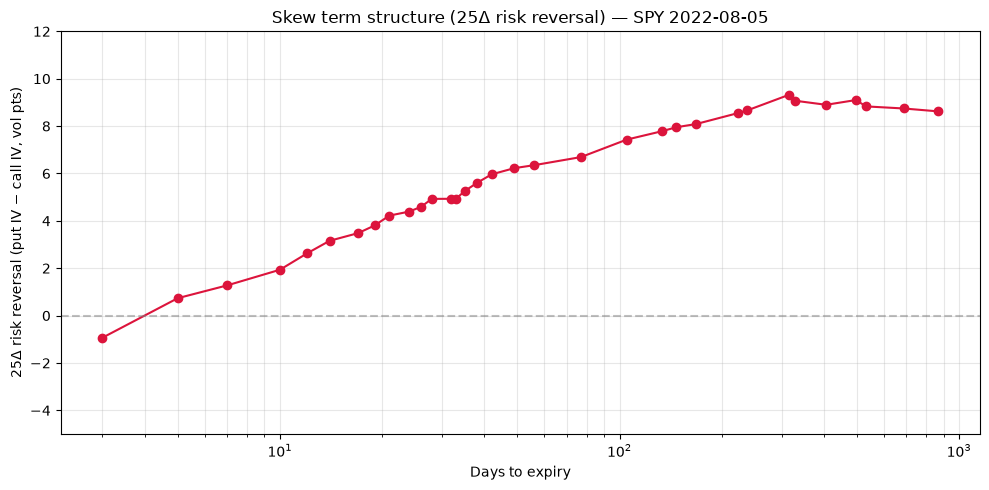


25-delta risk reversal by maturity (vol points):
   DTE  RR_25d
  3.00  -0.934
  5.00   0.735
  7.00   1.278
 10.00   1.936
 12.00   2.622
 14.00   3.157
 17.00   3.483
 19.00   3.805
 21.00   4.221
 24.00   4.390
 26.00   4.587
 28.00   4.927
 32.00   4.931
 33.00   4.935
 35.00   5.256
 38.00   5.599
 42.00   5.962
 49.00   6.225
 56.00   6.349
 77.00   6.692
105.04   7.430
133.04   7.780
147.04   7.952
168.04   8.086
224.00   8.554
238.00   8.665
315.00   9.316
329.00   9.070
406.00   8.899
497.04   9.100
532.04   8.831
686.00   8.744
868.04   8.621
  day    spot  atm_iv  rr_25d  med_spread   pcr
08-01 410.720  19.947   5.812       0.704 1.365
08-02 408.130  21.050   6.796       0.656 1.204
08-03 414.410  19.776   5.173       0.807 1.132
08-04 414.200  19.274   5.803       0.690 1.175
08-05 413.440  18.146   4.931       0.796 1.288


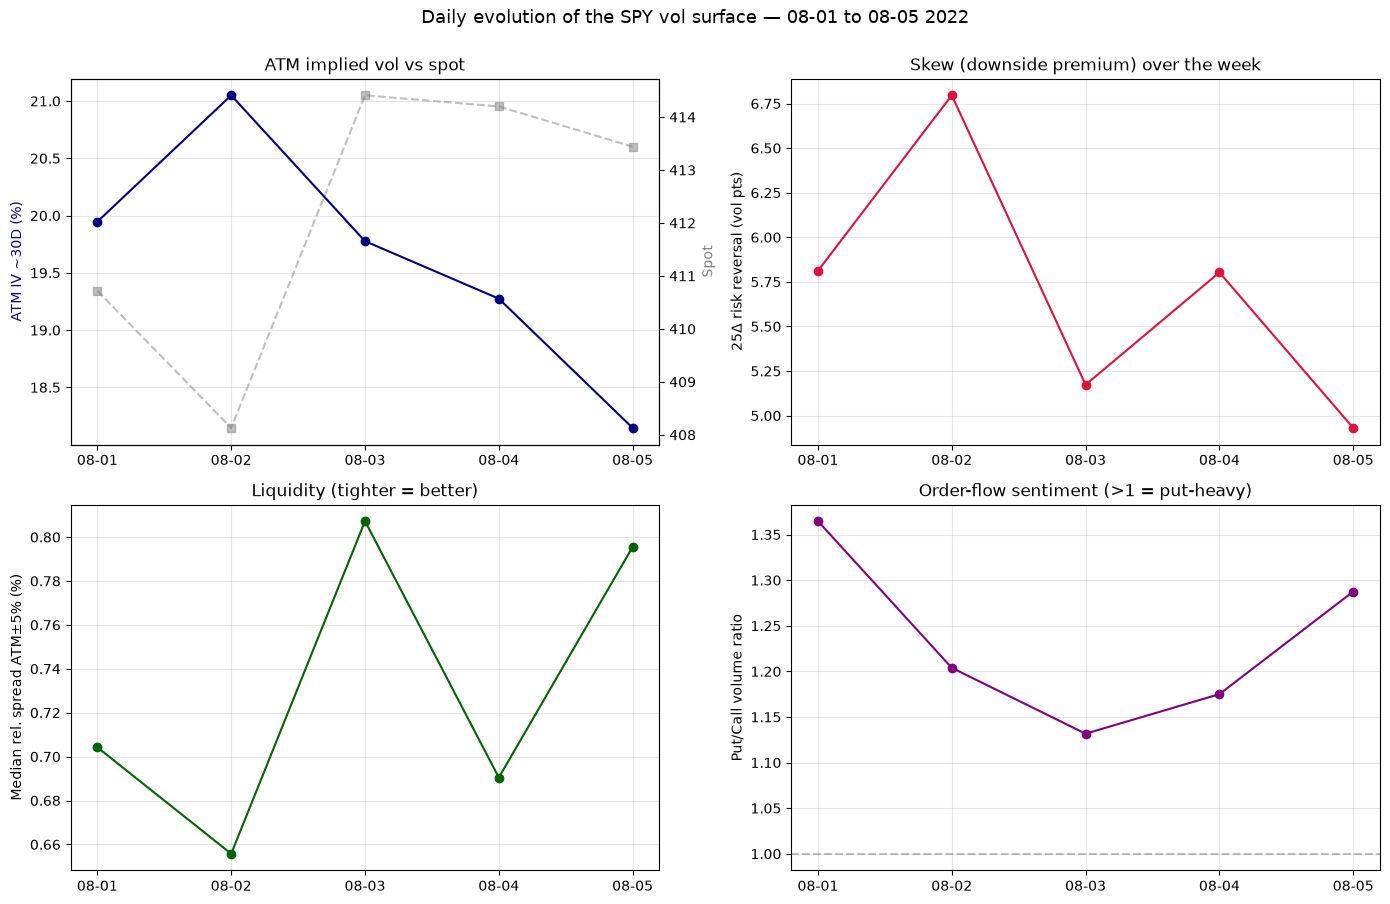

In [ ]:
'Cell 5: Implied Volatility'

# for a single trading day, the last trading day 2022-08-05
snap_date = data['QUOTE_READTIME'].max()
snap = data[data['QUOTE_READTIME'] == snap_date].copy()
spot = snap['UNDERLYING_LAST'].iloc[0]
print(f"Snapshot:{snap_date} | Spot:{spot:.2f}")

# Volatility Smile
# OTM options drive the smile, so I will use OTM options
snap['otm_iv'] = np.where(snap['STRIKE'] < spot, snap['P_IV'], snap['C_IV'])

target_dtes = [7, 30, 60, 90]
fig, ax = plt.subplots(figsize=(10,6))
for tdte in target_dtes:
    # grab the expiry closest to each DTE
    nearest = snap.iloc[(snap['DTE'] - tdte).abs().argsort()]['DTE'].iloc[0]
    # .argsort() — 返回"按距离从小到大排序"的索引顺序，排序后的位置索引
    # snap.iloc[...] — 按索引顺序重排整个表（最接近目标的排最前）
    # "找最接近目标值的记录"：数据里不一定正好有"7 天到期"的合约，找到最接近 7 天的真实到期日。

    # filter:
    sub = snap[(snap['DTE'] == nearest) &
               (snap['MONEYNESS_PCT'].abs() < 15) &
               (snap['otm_iv'] > 0.01) &
               (snap['otm_iv'] < 3)
               ].sort_values('STRIKE')
    ax.plot(sub['MONEYNESS_PCT'], sub['otm_iv'] * 100,
            marker='.', label=f'{int(nearest)} DTE')
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Moneyness (% from spot)')
ax.set_ylabel('Implied volatility (%)')
ax.set_title(f'Volatility smile / skew — SPY {snap_date.date()}')
ax.legend(title='Maturity')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ATM Term Structure
# ATM IV per expiry: average call & put IV for the strike nearest spot
term = []
# 每组 grp 是同一到期日的整条期权链（各种 strike）
for dte, grp in snap.groupby('DTE'):
    atm_row = grp.iloc[(grp['STRIKE'] - spot).abs().argsort()].iloc[0]
    cv, pv = atm_row['C_IV'], atm_row['P_IV']
    ''' 
    理论上（put-call parity）同一 strike 的 call IV 和 put IV 应该相等，
    但实际数据里两者总有小差异（bid-ask 噪声、报价时间戳不完全同步、数据商求解误差）。
    平均是降噪：两个含噪声的同一量的观测，取均值方差减半。
    行业惯例——ATM vol 通常报 call/put 均值
    '''
    atm_iv = np.nanmean([cv, pv]) # np.nanmean 如果一侧是 NaN，则只使用另一侧求平均
    if atm_iv > 0:
        term.append((dte, atm_iv))
term = pd.DataFrame(term, columns=['DTE', 'ATM_IV']).sort_values('DTE')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(term['DTE'], term['ATM_IV'] * 100, marker='o')
ax.set_xlabel('Days to expiry')
ax.set_ylabel('ATM implied volatility (%)')
ax.set_title(f'ATM term structure — SPY {snap_date.date()}')
ax.set_xscale('log')   # log scale so short end is readable
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Option skewness: measure the fear of the downside risk
# 计算方式：25d put IV - 25d call IV, per expiry
rr = []
for dte, grp in snap.groupby("DTE"):
    # 计算 risk reversal 需要四个值齐全
    g = grp.dropna(subset=['C_DELTA', 'P_DELTA', 'C_IV', 'P_IV']) 
    g = g[g['DTE'] >= 1] # drop 0DTE: deltas/IV unstable, RR unreliable
    # 到期日当天，delta 趋于阶跃函数——价内的瞬间变成 1、价外的瞬间变成 0，中间几乎没有过渡
    if len(g) < 5: # 样本如果太少则直接跳过
        continue
    # +- 0.25 delta for call and put
    call_25 = g.iloc[(g['C_DELTA'] - 0.25).abs().argsort()].iloc[0]
    put_25 = g.iloc[(g['P_DELTA'] + 0.25).abs().argsort()].iloc[0]

    if call_25['C_IV'] > 0 and put_25['P_IV'] > 0: # 确保两侧 IV 都是有效的，IV > 0
        rr.append((dte, (put_25['P_IV'] - call_25['C_IV']) * 100))

rr = pd.DataFrame(rr, columns=['DTE', 'RR_25d']).sort_values('DTE')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rr['DTE'], rr['RR_25d'], marker='o', color='crimson')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Days to expiry')
ax.set_ylabel('25Δ risk reversal (put IV − call IV, vol pts)')
ax.set_title(f'Skew term structure (25Δ risk reversal) — SPY {snap_date.date()}')
ax.set_xscale('log')
ax.set_ylim(-5, 12)  
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("\n25-delta risk reversal by maturity (vol points):")
print(rr.to_string(index=False))


# Time Series for the volatility
daily = []
for qdate, snap in data.groupby("QUOTE_READTIME"): # 将整个报价按照日期分成5组
    spot = snap['UNDERLYING_LAST'].iloc[0]

    # ATM IV: use ~30DTE expiry, strike nearest spot, avg of call & put IV
    # 计算当天的 ATM IV（30天到期）
    near30 = snap.iloc[(snap['DTE'] - 30).abs().argsort()]['DTE'].iloc[0] # 找最接近 30 天的到期日
    e30 = snap[snap['DTE'] == near30] # 筛出这个到期日的所有合约
    # 在 e30 中找到 strike 最接近现价的合约
    atm_row = e30.iloc[(e30['STRIKE'] - spot).abs().argsort()].iloc[0] 
    # 取到 C_IV and P_IV 的平均   
    atm_iv = np.nanmean([atm_row['C_IV'], atm_row['P_IV']]) * 100

    # 25delta risk reversal at ~30DTE
    g = e30.dropna(subset = ['C_DELTA', 'P_DELTA', 'C_IV', 'P_IV'])
    rr = np.nan
    if len(g) >= 5:
        c25 = g.iloc[(g['C_DELTA'] - 0.25).abs().argsort()].iloc[0]
        p25 = g.iloc[(g['P_DELTA'] + 0.25).abs().argsort()].iloc[0]
        if c25['C_IV'] > 0 and p25['P_IV'] > 0:
            rr = (p25['P_IV'] - c25['C_IV']) * 100
    
    # Median near-money relative spread (liquidity), 8-90 DTE, ATM ±5%
    # 筛选 ATM ±5%、8-90天的合约
    liq = snap[(snap['MONEYNESS_PCT'].abs() <= 5) &
               (snap['DTE'].between(8, 90))].copy()
    is_call = liq['STRIKE'] >= spot
    # 取价外侧的 rel spread
    liq['rel'] = np.where(is_call, liq['C_REL_SPREAD'], liq['P_REL_SPREAD'])
    liq = liq[(liq['rel'] > 0) & (liq['rel'] < 2)]
    med_spread = liq['rel'].median() * 100

    # Put/Call volume ratio, near-money
    near = snap[snap['MONEYNESS_PCT'].abs() <= 10]
    pcr = near['P_VOLUME'].sum() / near['C_VOLUME'].sum()

    daily.append({'date': qdate, 'spot': spot, 'atm_iv': atm_iv,
                  'rr_25d': rr, 'med_spread': med_spread, 'pcr': pcr})

ts = pd.DataFrame(daily).sort_values('date').reset_index(drop=True)
ts['day'] = ts['date'].dt.strftime('%m-%d')
print(ts[['day', 'spot', 'atm_iv', 'rr_25d', 'med_spread', 'pcr']].to_string(
    index=False, float_format=lambda x: f'{x:.3f}'))

# Daily ecolution for the volatility
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(ts['day'], ts['atm_iv'], marker='o', color='navy')
ax2 = ax.twinx()
ax2.plot(ts['day'], ts['spot'], marker='s', color='gray', alpha=0.5, ls='--')
ax.set_ylabel('ATM IV ~30D (%)', color='navy'); ax2.set_ylabel('Spot', color='gray')
ax.set_title('ATM implied vol vs spot'); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(ts['day'], ts['rr_25d'], marker='o', color='crimson')
ax.set_ylabel('25Δ risk reversal (vol pts)')
ax.set_title('Skew (downside premium) over the week'); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(ts['day'], ts['med_spread'], marker='o', color='darkgreen')
ax.set_ylabel('Median rel. spread ATM±5% (%)')
ax.set_title('Liquidity (tighter = better)'); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(ts['day'], ts['pcr'], marker='o', color='purple')
ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_ylabel('Put/Call volume ratio')
ax.set_title('Order-flow sentiment (>1 = put-heavy)'); ax.grid(alpha=0.3)

plt.suptitle(f'Daily evolution of the SPY vol surface — {ts["day"].iloc[0]} to {ts["day"].iloc[-1]} 2022',
             y=1.00, fontsize=13)
plt.tight_layout()
plt.show()


### 波动率分析
***Volitality Analysis***
- 做市商交易的不是方向，是波动率（volatility）
- Market Maker 不赌方向，而是在买卖隐含波动率。
- 期权价格 = 模型(标的价, 行权价, 到期时间, 利率, 波动率)，但是现实中，隐含波动率 = 把市场期权价格代入 BS 模型，反推出来的那个波动率。

---

***Option：期权投资组合分析***

**1. 组合构造**

时刻 $t$,做市商卖出 1 份 call,价格 $V(S,t)$,并持有 $\Delta_t$ 份标的对冲。组合价值:

$$\Pi_t = -V(S_t, t) + \Delta_t S_t - B_t$$

其中 $\Delta_t = \dfrac{\partial V}{\partial S}$(连续 re-hedge，组合瞬时 delta 中性)，$B_t$ 为融资账户(借入资金买标的的负债)。

$S$：标的，$r$：无风险利率，$q$：分红率，$\sigma_{imp}$：定价用隐含波动率，$\sigma_{real}$：实际波动率。

**2. 单期 P&L 分解(Itô 展开)**

对卖方而言,持有期权空头 + delta 对冲,一个小区间 $dt$ 内的损益用 Itô 引理展开 $dV$:

$$dV = \frac{\partial V}{\partial t}\,dt + \frac{\partial V}{\partial S}\,dS + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}\,(dS)^2$$

即

$$dV = \Theta\,dt + \Delta\,dS + \frac{1}{2}\Gamma\,(dS)^2 $$

delta-hedged 组合(空头期权 + $\Delta$ 份标的,忽略融资项先看核心结构)的损益:

delta-hedge 说明 $\Delta = \partial_S V$，同时，无风险组合所取得的收益应该是 $r$。

$$d\Pi = -dV + \Delta\,dS = -\Theta\,dt - \frac{1}{2}\Gamma\,(dS)^2 = r (-V + \Delta S) dt$$

$\Delta\,dS$ 项被对冲精确抵消,**方向风险消失**,只剩 $\Theta$ 与 $\Gamma$ 两项。

在 delta hedge 之后只剩 gamma/theta 暴露。

**3. 波动率代入**

关键一步:$\Theta$ 是按 $\sigma_{imp}$ 定价得到的(BS 方程约束),而 $(dS)^2$ 是市场**真实**实现的。

Ito 引理：

$$
df(t,X_t)=\frac{\partial f}{\partial t}\,dt+\frac{\partial f}{\partial x}\,dX_t+\frac{1}{2}\frac{\partial^2 f}{\partial x^2}\,dX_tdX_t
$$

设 $dX_t=\mu_t\,dt+\sigma_t\,dW_t$,则对 $f(t,x)\in C^{1,2}$:

$$
df(t,X_t)=\Big(\underbrace{\frac{\partial f}{\partial t}+\mu_t\frac{\partial f}{\partial x}+\frac{1}{2}\sigma_t^2\frac{\partial^2 f}{\partial x^2}}_{\text{漂移项}}\Big)dt+\underbrace{\sigma_t\frac{\partial f}{\partial x}}_{\text{扩散项}}\,dW_t
$$

用 Greeks 记号替换偏导后得到，BS PDE 下 theta 与 gamma 在隐含波动率下的恒等关系(delta 中性、为简洁设 $q=0$):

$$\Theta + \frac{1}{2}\sigma_{imp}^2 S^2 \Gamma + rS\Delta - rV = 0 \;\Rightarrow\; \Theta \approx -\frac{1}{2}\sigma_{imp}^2 S^2 \Gamma \quad(\text{忽略 } r \text{ 项})$$

而实现的二次变差:

$$(dS)^2 = \sigma_{real}^2 S^2\, dt$$

代回 $d\Pi$:

$$\boxed{\,d\Pi = -\Theta\,dt - \frac{1}{2}\Gamma (dS)^2 = \frac{1}{2}S^2\Gamma\big(\sigma_{imp}^2 - \sigma_{real}^2\big)\,dt\,}$$

**结论**:卖方瞬时 P&L 正比于 $\sigma_{imp}^2 - \sigma_{real}^2$,加权系数为 dollar gamma $\frac{1}{2}S^2\Gamma$。

- $\sigma_{real} < \sigma_{imp} \;\Rightarrow\; d\Pi > 0$(赚)
- $\sigma_{real} > \sigma_{imp} \;\Rightarrow\; d\Pi < 0$(亏)


**4. 整个持有期的累计 P&L**

对路径积分,总损益可得到**gamma P&L / volatility P&L** 公式：

$$\Pi_{total} = \frac{1}{2}\int_0^T S_t^2\,\Gamma_t\,\big(\sigma_{imp}^2 - \sigma_{real,t}^2\big)\,dt$$

注意它是 **path-dependent**:权重 $S_t^2\Gamma_t$ 沿路径变化,标的停留在 gamma 大的区域(ATM)时,波动率差异的影响被放大。

买方(long option / long gamma / short theta)：
- 盈利： $\sigma_{real} > \sigma_{imp}$
- 成本： 每天付出 theta (时间衰减,持仓价值减少)

卖方(short option / short gamma / long theta)：
- 盈利：收取 theta（时间租金）
- 成本：承担波动率风险，收益有限(最多赚到全部权利金/theta),亏损可能很大。

--- 
***Volatility Smile***

概念：理论上 IV 应该是平的，但现实不是。Black-Scholes 模型中假设：波动率是常数，但实际上并不是如此。

同一到期日、不同 strike 的 IV 画出来，得到一条弯曲的曲线
- 微笑（smile）：两边高、中间低（U 型）——常见于外汇、短期期权
- 偏斜（skew / smirk）：左边高、右边低（下行倾斜）——股指期权的典型形态

为什么股指是左高右低（负偏斜）？ 金融直觉：

1. 投资者持续买 put 对冲下跌：机构手里有大量股票，怕跌，长期买入价外 put 做保险。这个持续的买盘需求推高了 put 的价格，也就推高了 put 端（低 strike）的 IV。
2. 崩盘比暴涨更剧烈：股市"跌起来又快又狠，涨起来慢慢爬"（杠杆效应 + 恐慌情绪）。市场知道这点，给下行（低 strike）定了更高的波动率预期。
结果：低 strike（put 端）IV 高，高 strike（call 端）IV 低 → 曲线左高右低。
3. 这个左高右低的形态就是著名的 equity skew（股指偏斜），也叫"波动率微笑的左偏"。它反映的是市场对下跌的恐惧溢价。因为 put 的隐含波动率（市场愿意付的保险费）系统性地高于实际兑现的波动率——为variance risk premium（方差风险溢价）。
4. 注意：这里的套利空间为：delta-hedged short put，即做空波动率，但是卖出 put 后整体为负gamma，一直调整re-hedge会导致不断"高买低卖"，同时可能承担一定的尾部风险。

--- 

***Term Structure***

固定在平值（ATM），分析 IV 随到期时间的变化。

- 定价标尺：term structure 是 MM 给不同到期日库存"标价"的基准。比如一个 60 天的 ATM 期权该用多少 IV 定价，根据该曲线定价。

- 判断市场状态：向上倾斜=平静，可以正常做市；如果哪天突然倒挂（短端 IV 飙过长端），是危机信号，MM 要立刻收紧风险、加宽价差。

1. 向上倾斜（contango）—— 平静市场的常态
    
    近期 IV 低，远期 IV 高
    直觉：当下风平浪静（近期没什么可担心的），但越往远看不确定性越大（远期可能发生各种事），所以远期波动率定得更高。

2. 向下倾斜 / 倒挂（backwardation）—— 危机/恐慌市场

    近期 IV 高，远期 IV 低
    直觉：眼前正在发生危机（近期极度恐慌、波动剧烈），但市场相信"风暴会过去"，远期会回归正常出现倒挂。通常是市场压力的信号（比如崩盘当下、重大事件前夜）。

目前图形显示，整体形态是向上倾斜（contango），对应"平静市场"。极短端 IV 异常低（3DTE ≈ 10.5%），同时中段（10-40 天）锯齿状波动，可能包含了某些特殊事件（CPI数据、FOMC会议等），长端走平甚至略降（200DTE 后稳定在 ~22.7% 并微微回落），反映 波动率均值回归（mean reversion） 被定进了曲线，市场认为波动率长期会回到某个"正常水平"。同时短端具有一定特殊性，极短端 IV 又低又不稳（对单日事件敏感），对应价差分析中 0-7d 价差宽——短端是 gamma 风险高、定价不稳的区域。

---

***Option Skew***

量化 skew，业界通常用 delta 坐标进行量化。

原因：delta计算当中，带有$\sigma \sqrt{T}$ 将波动率和到期进行归一化，跨到期可比，即一月到期与一年到期是可比的。而 moneyness 跨期不可比。比如：对于一个月期权，典型波动幅度为 ±5%，而对于一年期权，典型波动幅度为 ±20%，因此对于同一个 moneyness，比如现价下方 5%，两者的风险价位是不同的。

一般而言，put IV > call IV，同时 delta ≈ 到期变成实值的概率，将 strike 翻译为了一个概率。当 delta = 0.5 时，K = S，即为 ATM，而当 delta = 0.01 or 0.05时，即为深度虚值（deep OTM），信号最强但那里几乎不成交、报价全是噪声。而delta = 0.25 时，为中度 OTM，离尾部较近，又处于活跃交易区，信噪比最优。

Risk Reversal：（衡量曲线不对称性）

曲线在 0 线上方（正值），RR > 0 = put IV 高于 call IV = 市场为下行保护付的溢价高于上行。这是股指经典的下行恐惧（put skew）。Risk Revsersal 随期限单调上升。

--- 

时间序列下的波动率分析 （Time Series Volatility）

- 中心事件：08-02 那天市场最恐慌，之后逐步转向平静。同时，在 08-02，skew达到了最高点，表明了恐慌的方向倾斜，说明市场具有下跌恐慌。




Put-Call Parity check - SPY 2022-08-05, Spot = 413.44

    DTE  implied_fwd  implied_r_%  max_abs_resid  rms_resid  n
  3.000      413.461       -5.707          0.070      0.019 82
  5.000      413.491       -7.032          0.046      0.016 82
  7.000      413.536      -12.525          0.141      0.038 90
 10.000      413.551      -10.068          0.150      0.049 82
 12.000      413.583       -8.749          0.098      0.044 82
 14.000      413.645       -9.230          0.123      0.061 88
 17.000      413.670       -8.333          0.125      0.068 49
 19.000      413.713       -7.253          0.163      0.068 65
 21.000      413.794       -6.165          0.236      0.082 77
 24.000      413.822       -5.614          0.278      0.092 69
 26.000      413.869       -5.474          0.208      0.075 65
 28.000      413.905       -8.028          0.306      0.132 72
 32.000      413.923       -6.700          0.292      0.122 65
 33.000      413.897       -5.859          0.618      0.190 45


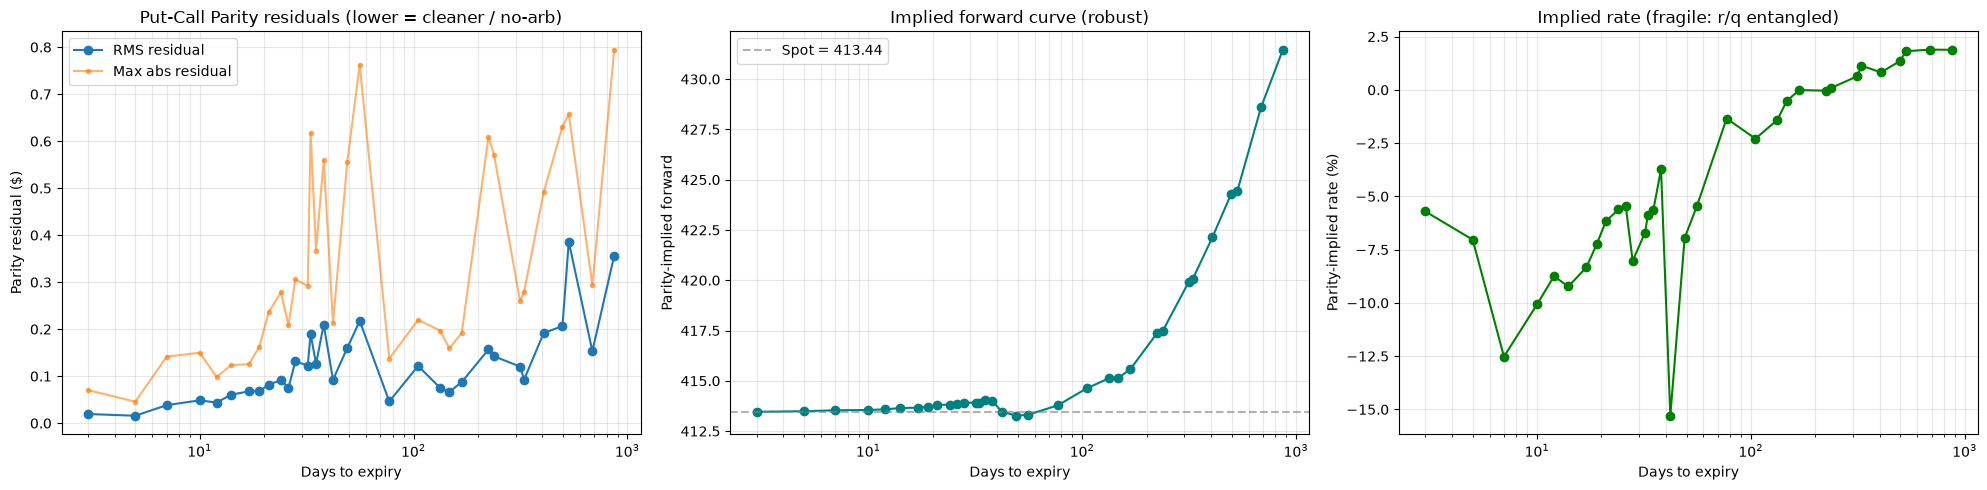

In [21]:
'Cell 6: Put-Call Parity'

snap_date = data['QUOTE_READTIME'].max()
snap = data[data['QUOTE_READTIME'] == snap_date].copy()
spot = snap['UNDERLYING_LAST'].iloc[0]

# Put-Call Parity
# Practical test: C_mid - P_mid should be a near-linear function of K
# For each expiry, C - P = -K*e^(-rT) + F*e^(-rT) - linear in K with slope ~ -e^(-rT)

pcp = snap.dropna(subset=['C_MID', 'P_MID', 'STRIKE']).copy()
pcp = pcp[(pcp['C_MID'] > 0) & (pcp['P_MID'] > 0)] # need real two-sided quotes
pcp = pcp[pcp['MONEYNESS_PCT'].abs() <= 10] # near the money: most reliable
pcp['cmp'] = pcp['C_MID'] - pcp['P_MID'] # call mid - put mid

results = []
for dte, grp in pcp.groupby('DTE'):
    if len(grp) < 5 or dte < 1: # 按到期日分组（每个到期日是一条独立的直线，要分开拟合)
        continue

    # C − P = (−e^(−rT))·K + (F·e^(−rT)) = a·K + b
    K = grp['STRIKE'].values
    y = grp['cmp'].values
    a, b = np.polyfit(K, y, 1) # 对每个到期日做线性拟合 np.polyfit(X, y, n) n为多项式次数
    resid = y - (a * K + b)
    # Implied forward and rate from the fit
    disc = -a # disc = e^(-rT)
    fwd = b / disc if disc > 0 else np.nan # 反解得到 forward price
    T = dte / 365.0 
    implied_r = -np.log(disc) / T if (disc > 0 and T > 0) else np. nan
    results.append({
        'DTE':dte,
        'implied_fwd':fwd,
        'implied_r_%':implied_r * 100,
        'max_abs_resid':np.abs(resid).max(),
        'rms_resid':np.sqrt((resid ** 2).mean()),
        'n':len(grp),
    })

pcp_res = pd.DataFrame(results).sort_values('DTE')
print(f'Put-Call Parity check - SPY {snap_date.date()}, Spot = {spot:.2f}\n')
print(pcp_res.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# parity residuals + implied rate + implied forward
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Panel 1: residuals (data quality / no-arb) ---
axes[0].plot(pcp_res['DTE'], pcp_res['rms_resid'], marker='o', label='RMS residual')
axes[0].plot(pcp_res['DTE'], pcp_res['max_abs_resid'], marker='.', alpha=0.6, label='Max abs residual')
axes[0].set_xscale('log')
axes[0].set_xlabel('Days to expiry')
axes[0].set_ylabel('Parity residual ($)')
axes[0].set_title('Put-Call Parity residuals (lower = cleaner / no-arb)')
axes[0].legend()
axes[0].grid(alpha=0.3, which='both')

# --- Panel 2: implied forward (the ROBUST output) ---
axes[1].plot(pcp_res['DTE'], pcp_res['implied_fwd'], marker='o', color='teal')
axes[1].axhline(spot, color='gray', ls='--', alpha=0.6, label=f'Spot = {spot:.2f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Days to expiry')
axes[1].set_ylabel('Parity-implied forward')
axes[1].set_title('Implied forward curve (robust)')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

# --- Panel 3: implied rate (the FRAGILE output) ---
axes[2].plot(pcp_res['DTE'], pcp_res['implied_r_%'], marker='o', color='green')
axes[2].set_xscale('log')
axes[2].set_xlabel('Days to expiry')
axes[2].set_ylabel('Parity-implied rate (%)')
axes[2].set_title('Implied rate (fragile: r/q entangled)')
axes[2].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()


***Put-Call Parity***

Put-Call Parity 是某一时刻的关系，固定一天，取单日快照。

核心等式：$C − P = S·e^{−qT} − K·e^{−rT}$  => C - P is linear in $K$

其中 r = 无风险利率，q = 股息率，T = 到期时间。


$C − P = (−e^{−rT})·K + (F·e^{−rT}) = a·K + b$

- 可以通过反解得到 risk-free rate 和 forward price

---

***统计原理***

**统计原理一：自由度（degrees of freedom）**

自由度 = 样本数 n − 参数个数

- 数据点远多于参数，直线被"很多点共同约束"，拟合稳定，残差能真实反映"数据贴不贴合直线"。
- 数据点少，直线被少数点牵着走，个别点的位置对拟合结果影响很大。

**统计原理二：估计量的方差随 n 增大而减小**

中心极限定理（Central Limit Theorem） 以及 样本均值的方差公式

如果你从一个总体里独立抽取 n 个样本，样本均值的标准误(standard error)= 总体标准差 σ 除以 $\sqrt{n}$：

$$SE = \sigma / \sqrt{n}$$

估计量的标准误 $∝ 1/\sqrt{n}$

**统计原理三：小样本对离群点没有"稀释能力"**

RMS的无偏估计：$$\text{RMS} = \sqrt{\frac{1}{n-2} \sum_{i=1}^{n} r_i^2}$$ 

RMS 残差 = $\sqrt{残差平方的平均}$。一个离群点（比如某个 strike 报价偏了 $0.5）对 RMS 的影响，取决于它在多少个点里"被平均"：

n = 80：1 个离群点的平方误差被 80 个数平均，影响被稀释到 1/80，RMS 几乎不动
n = 16：同一个离群点被 16 个数平均，影响是 1/16，对 RMS 的拉动大 5 倍

---

***Analysis***

通过代码反解出的利率 Implied Rate 是负的，而是单因子拟合的局限，真实公式有股息 $C − P = S·e^{−qT} − K·e^{−rT}$，线性拟合只能解出一个折现因子，无法分离 r 和 q。

原因：
- 近月 T = 30 以内时，斜率会对噪声极度敏感，r = −ln(disc)/T，当 T 极小时，即使一点点噪声，也会造成 r 不稳定。近月 T 极小，分母 T 很小，任何斜率的微小误差经过 −ln(disc)/T 都会被放大几十倍。
- 真实的 parity 在有离散股息时是： C − P = S − PV(dividends) − K·e^(−rT)，PV(dividends) 是到期前所有现金股息的现值。这一项严格说会让"有效斜率"偏离 −e^(−rT)，因为离散股息的影响没法干净地塞进截距，会渗进斜率的估计。

**Graph 1**

- RMS Residual：近月只有 2-10 美分，即使最大也就 0.4 美元。对一个现价 $413 的标的，几美分的 parity 残差意味着 call/put 报价高度一致，没有可套利的错价。

- 同时，两条折线从左到右往上爬——长端残差明显大于近月。但是这不是由于数据质量导致的，而是样本问题产生的。长端到期日的 strike 数量少（n≈16），而近月 strike 密集（n=80+）。样本少 → 拟合不稳定 → 残差自然偏大，这是统计上的必然，不代表报价错。

**Graph 3**

- 近月利率为负（-5% 到 -15%），长端才转正到 +2%，但是这不是真负利率，是 r 和 q 没分离的假象。SPY 有季度股息，股息被折进了估计，在近月把"利率"拉成负的。
    
    近月：股息的离散扰动相对 T 占比大，主导了估计，拉成负值
    
    长端：T 长，股息被年化摊薄，r 逐渐主导，反解接近真实净利率（+2% 左右，合理）

因此，稳健、可用的输出是 forward 曲线，而非利率曲线。


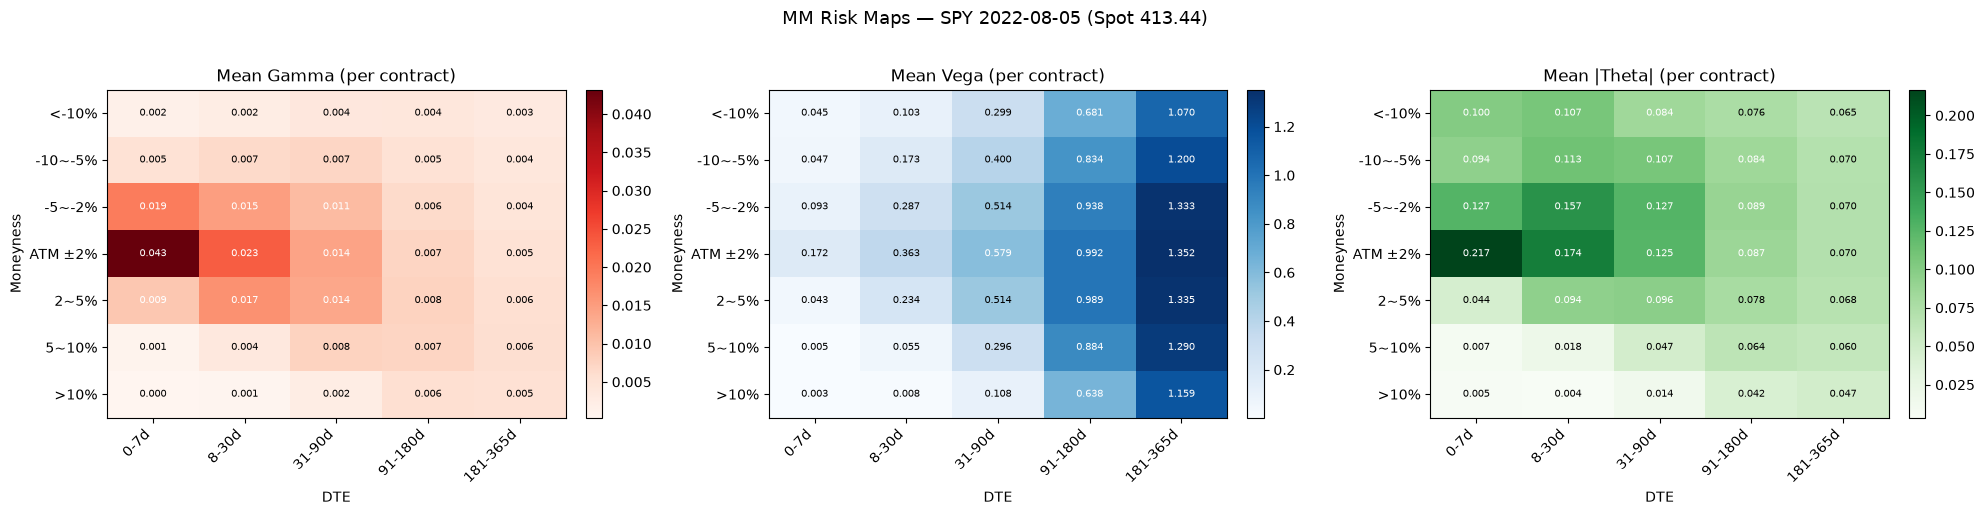

GAMMA (rows=moneyness, cols=DTE)
dte_bucket    0-7d   8-30d  31-90d  91-180d  181-365d
m_bucket                                             
<-10%       0.0016  0.0023  0.0038   0.0038    0.0032
-10~-5%     0.0051  0.0066  0.0070   0.0051    0.0039
-5~-2%      0.0193  0.0149  0.0110   0.0064    0.0045
ATM ±2%     0.0432  0.0232  0.0141   0.0073    0.0051
2~5%        0.0093  0.0165  0.0136   0.0077    0.0056
5~10%       0.0010  0.0036  0.0077   0.0072    0.0057
>10%        0.0003  0.0005  0.0025   0.0055    0.0052

VEGA
dte_bucket   0-7d  8-30d  31-90d  91-180d  181-365d
m_bucket                                           
<-10%       0.045  0.103   0.299    0.681     1.070
-10~-5%     0.047  0.173   0.400    0.834     1.200
-5~-2%      0.093  0.287   0.514    0.938     1.333
ATM ±2%     0.172  0.363   0.579    0.992     1.352
2~5%        0.043  0.234   0.514    0.989     1.335
5~10%       0.005  0.055   0.296    0.884     1.290
>10%        0.003  0.008   0.108    0.638     1.159

|THETA

In [22]:
'Cell 7: the Greeks'

snap_date = data['QUOTE_READTIME'].max()
snap = data[data['QUOTE_READTIME'] == snap_date].copy()
spot = snap['UNDERLYING_LAST'].iloc[0]

# focus on the tradable surface
risk = snap[(snap['MONEYNESS_PCT'].abs() <= 15) & (snap['DTE'] <= 365) & snap['DTE'] >= 1].copy()

# Moneyness & DTE buckets
risk['m_bucket'] = pd.cut(risk['MONEYNESS_PCT'],
                          bins=[-15, -10, -5, -2, 2, 5, 10, 15],
                          labels=['<-10%','-10~-5%','-5~-2%','ATM ±2%','2~5%','5~10%','>10%'])
risk['dte_bucket'] = pd.cut(risk['DTE'],
                            bins=[0, 7, 30, 90, 180, 365],
                            labels=['0-7d','8-30d','31-90d','91-180d','181-365d'])

# Greeks are reported per contract; call & put gamma/vega are ~ equal at the same strike
# use the call leg as the representative magnitude (abs value)
risk['gamma'] = risk['C_GAMMA'].abs()
risk['vega']  = risk['C_VEGA'].abs()
risk['theta'] = risk['C_THETA'].abs()

def heat(col, title, ax, cmap):
    piv = risk.pivot_table(values=col, index='m_bucket', columns='dte_bucket',
                           aggfunc='mean', observed=True)
    im = ax.imshow(piv.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_title(title); ax.set_xlabel('DTE'); ax.set_ylabel('Moneyness')
    # annotate
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=7,
                        color='white' if v > np.nanmean(piv.values) else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return piv

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
g_piv = heat('gamma', 'Mean Gamma (per contract)', axes[0], 'Reds')
v_piv = heat('vega',  'Mean Vega (per contract)',  axes[1], 'Blues')
t_piv = heat('theta', 'Mean |Theta| (per contract)', axes[2], 'Greens')
plt.suptitle(f'MM Risk Maps — SPY {snap_date.date()} (Spot {spot:.2f})', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print("GAMMA (rows=moneyness, cols=DTE)")
print(g_piv.round(4).to_string())
print("\nVEGA")
print(v_piv.round(3).to_string())
print("\n|THETA|")
print(t_piv.round(4).to_string())


***The Greeks***

Black-Scholes Formula:

$$
C(S_t, t) = S_t N(d_1) - K e^{-r(T-t)} N(d_2)
$$

Black-Scholes notation:

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

where $N(\cdot)$ is the standard normal CDF and $N'(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}$ is the PDF.

**Delta(Δ)**

$$\Delta = \frac{\partial V}{\partial S}, \qquad \Delta_{call} = N(d_1), \quad \Delta_{put} = N(d_1) - 1$$

Delta 衡量标的涨 \$1 期权价值变多少。Call ∈(0,1)，put ∈(-1,0)。

- Hedge ratio: a 0.5-delta call carries the directional risk of 0.5 shares.
- 近似于 probability of finishing ITM.

**Gamma**

$$\Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\partial \Delta}{\partial S} = \frac{N'(d_1)}{S\sigma\sqrt{T}}$$

- Gamma 衡量当现价变化时，delta的变化量。当期权处于 ATM 且临期时，到达最大值。同时 负Gamma 不利于卖方，标的价格变化之后，delta 朝不利方向变动，卖方被迫高买低卖进行对冲。

- The hardest risk to manage; concentrates in short-dated ATM (the 0DTE problem).

- 对于 call 和 put，Gamma 的表达式是一致的。

**Vega**

$$\nu = \frac{\partial V}{\partial \sigma} = S\sqrt{T}\,N'(d_1)$$

- Vega 衡量IV 涨 1% 期权价值变多少。永远为正。ATM 最大，随 $\sqrt{T}$ 增大 → 长期期权 vega 最大。
- 对于 MM 而言，Vega 是核心衡量 Core inventory risk. Long-dated ATM is the vega hotspot. 卖出期权等于 负 Vega。长期 ATM 是 Vega 风险集中区。

**Theta**

$$\theta_{call} = -\frac{S\,N'(d_1)\,\sigma}{2\sqrt{T}} - rKe^{-rT}N(d_2)$$

- Theta 衡量每天损失的价值(时间衰减)。当期权处于 ATM 且临期时，Theta到达最大值。

- Selling options = positive theta — earns decay as compensation for bearing negative gamma. / 卖期权=正 theta，靠时间衰减赚钱，作为承担负 gamma 的补偿。


**Rho**

$$\rho_{call} = KTe^{-rT}N(d_2), \qquad \rho_{put} = -KTe^{-rT}N(-d_2)$$

- Rho衡量Value change per 1% rate move. Usually least important; matters for long-dated (LEAPS). 对于长期期权而言，比较重要。

---

***Analysis***

Gamma 在 ATM ±2% × 0-7d = 0.0432 时为全表最大。Gamma 在ATM+短期时最大。

Vega 在 ATM 最大。当 MM 持有长期期权库存时，需要承担vega 风险（IV 一变，盯市盈亏剧烈波动），且长期 vega 难以对冲（需要用其他长期期权或 variance swap）。

Theta 峰值在 ATM + 短期，和 gamma 同位置。对于 MM 来说，短期 ATM 的 theta 收入是负 gamma 的补偿。MM 卖短期 ATM 期权，会收取期权的时间衰减。
